In [1]:
import numpy as np
import pickle
import sys
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot'])
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline

In [5]:
with open('objs.pkl','rb') as f:
    X, y, _ = pickle.load(f) # pandas objects!
max_iter = 2000

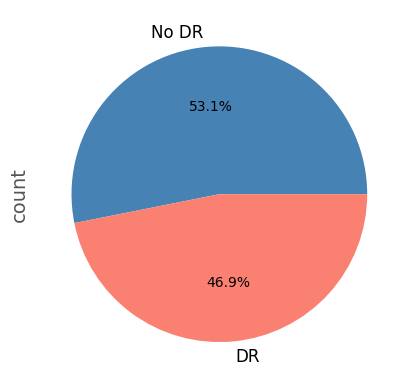

In [6]:
y.value_counts().plot(kind="pie", labels=['No DR','DR'], colors = ['steelblue', 'salmon'], autopct='%1.1f%%')
plt.show()

In [7]:
X = X.values
y = y.values

In [8]:
X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 10, stratify=y)

In [9]:
def check_penalty(penalty='none'):
    if penalty == 'l1':
        solver='liblinear'
    if penalty == 'l2' or penalty == 'none':
        solver='lbfgs'
    return solver

In [10]:
x_train_orig, x_val_orig, y_train, y_val= train_test_split(X_train, Y_train, test_size = 0.20, random_state = 10, stratify=Y_train)

In [11]:
#C1
scaler = StandardScaler()
solver = check_penalty(penalty='none')
#----------------------Implement your code here:------------------------------

#-----------------------------------------------------------------------------

processed: 8/8: 100%|██████████| 8/8 [00:00<00:00, 758.09it/s]


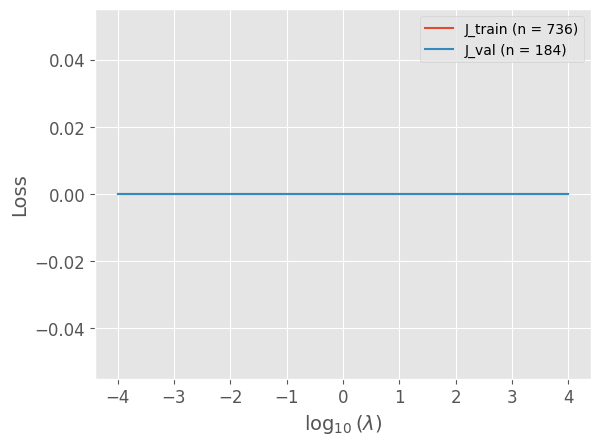

In [15]:
#C2
lmbda = np.array([0.0001, 0.001, 0.01, 1, 10, 100, 1000, 10000])
pen = 'l2'
solver = check_penalty(penalty=pen)
J_train = np.zeros_like(lmbda)
J_val = np.zeros_like(lmbda)
with tqdm(total=len(lmbda), file=sys.stdout) as pbar:
    for idx, lb in enumerate(lmbda):
        pbar.set_description('processed: %d/%d' % ((1 + idx), len(lmbda)))
        pbar.update(1)
        #----------------------Implement your code here:------------------------------

        #-----------------------------------------------------------------------------
plt.plot(np.log10(lmbda), J_train)
plt.plot(np.log10(lmbda), J_val)
plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel('Loss')
plt.legend(['J_train (n = ' + str(x_train_orig.shape[0]) + ')', 'J_val (n = ' + str(x_val_orig.shape[0]) + ')'])
plt.show()

processed: 10/10: 100%|██████████| 10/10 [00:00<00:00, 1160.73it/s]


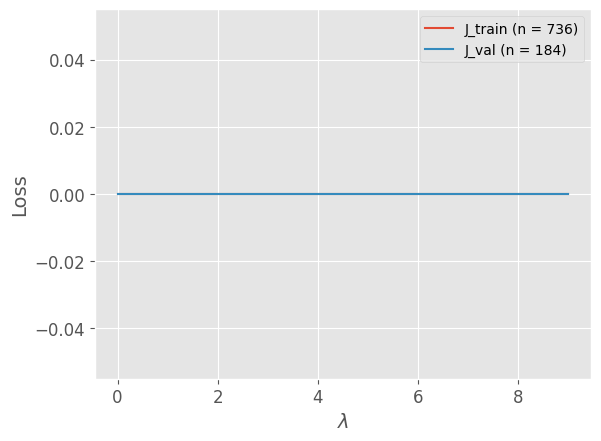

In [17]:
#C3
fine_lmbda = np.arange(0,10,1, dtype=np.float64)
J_train = np.zeros_like(fine_lmbda)
J_val = np.zeros_like(fine_lmbda)
with tqdm(total=len(fine_lmbda), file=sys.stdout) as pbar:
    for idx, lb in enumerate(fine_lmbda):
        pbar.set_description('processed: %d/%d' % ((1 + idx), len(fine_lmbda)))
        pbar.update(1)
        if lb-0.01 < 0:
            C = np.inf # equivalent to 'none' penalty
        else:
            C = 1/lb
        #----------------------Implement your code here:------------------------------

        #-----------------------------------------------------------------------------
plt.plot(fine_lmbda, J_train)
plt.plot(fine_lmbda, J_val)
plt.xlabel(r'$\lambda$')
plt.ylabel('Loss')
# plt.ylim(0.62, 0.68)
plt.legend(['J_train (n = ' + str(x_train_orig.shape[0]) + ')', 'J_val (n = ' + str(x_val_orig.shape[0]) + ')'])
plt.show()

In [18]:
# choose best lmbda
best_lmbda = 10

processed: 100/100: : 100it [00:00, 981.38it/s]                     


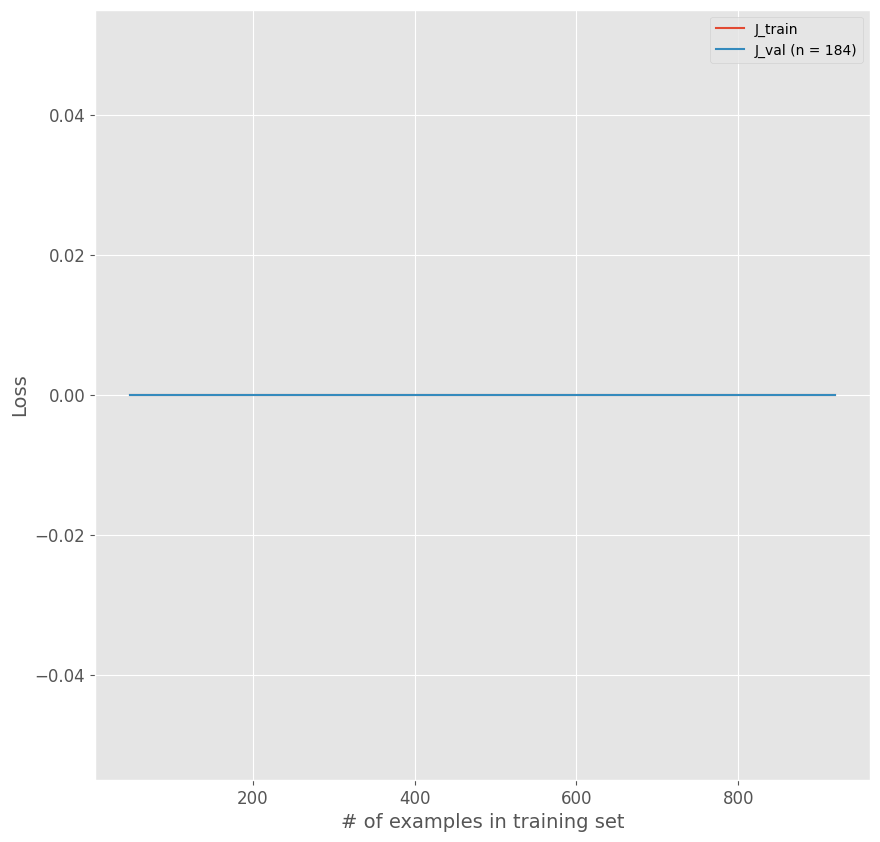

In [20]:
#C4
data_ratio = np.linspace(0.0028,0.998,num = 100)
J_train = np.zeros_like(data_ratio)
J_val = np.zeros_like(data_ratio)
log_reg = LogisticRegression(random_state=5, penalty=pen, C = 1/best_lmbda, max_iter=max_iter,solver=solver)
with tqdm(total=len(data_ratio)-1, file=sys.stdout) as pbar:
    for idx, curr_ratio in enumerate(data_ratio):
        pbar.set_description('processed: %d/%d' % ((1 + idx), len(data_ratio)))
        pbar.update(1)
        #----------------------Implement your code here:------------------------------

        #-----------------------------------------------------------------------------
fig, axes = plt.subplots(1,1,figsize=(10,10))
axes.plot(np.ceil(data_ratio[5:]*X_train.shape[0]), J_train[5:])
axes.plot(np.ceil(data_ratio[5:]*X_train.shape[0]), J_val[5:])
axes.set_xlabel('# of examples in training set')
axes.set_ylabel('Loss')
axes.legend(['J_train', 'J_val (n = ' + str(x_val_orig.shape[0]) + ')'])

8/8 lambda values, processed folds: 100%|██████████| 10/10 [00:00<00:00, 1090.14it/s]


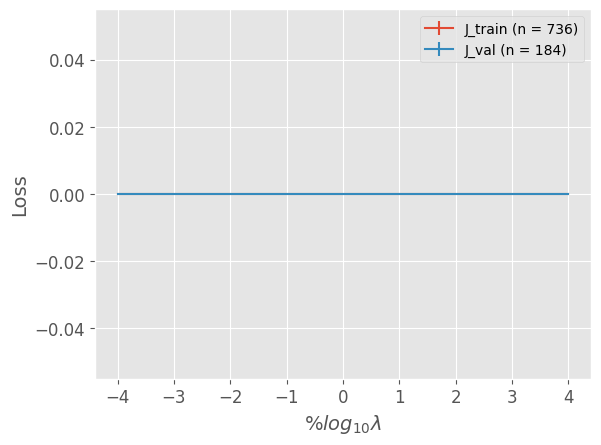

In [23]:
#C5
lmbda = np.array([0.0001, 0.001, 0.01, 1, 10, 100, 1000, 10000])
# fine_lmbda = np.linspace(0.1,5,num=20) # after seeing cross-fold on logscale
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, random_state=10, shuffle=True)

J_train = np.zeros((2,len(lmbda)))
J_val = np.zeros((2,len(lmbda)))

# pen = 'l2'
solver = check_penalty(penalty=pen)

for idx, lmb in enumerate(lmbda):
    C = 1/lmb
    #--------------------------Impelment your code here:-------------------------------------

    #----------------------------------------------------------------------------------------
    with tqdm(total=n_splits, file=sys.stdout, position=0, leave=True) as pbar:
        h = 0 # index per split per lambda
        J_train_fold = np.zeros(n_splits)
        J_val_fold = np.zeros(n_splits)

        for train_index, val_index in skf.split(X_train, Y_train):
            pbar.set_description('%d/%d lambda values, processed folds' % ((1 + idx), len(lmbda)))
            pbar.update()
            #--------------------------Impelment your code here:-------------------------------------

            #----------------------------------------------------------------------------------------
            h += 1
        #--------------------------Impelment your code here:-------------------------------------

        #----------------------------------------------------------------------------------------
plt.errorbar(np.log10(lmbda), J_train[0,:], yerr=J_train[1,:])
plt.errorbar(np.log10(lmbda), J_val[0,:], yerr=J_val[1,:])
plt.xlabel(r'$\%log_{10}\lambda$')
plt.ylabel('Loss')
plt.legend(['J_train (n = ' + str(x_train_orig.shape[0]) + ')', 'J_val (n = ' + str(x_val_orig.shape[0]) + ')'])

In [24]:
def max_data_ratio(n_splits,x_train,y_train):
    data_ratio_orig = np.linspace(0.01,0.98,num=100)
    k_min = 0
    m_x_train, _, m_y_train, _ = train_test_split(x_train, y_train, test_size =1-data_ratio_orig[k_min], random_state = 10,
                                     stratify=y_train)
    while (m_x_train[m_y_train>0.5,:].shape[0] <= n_splits) or (m_x_train[m_y_train<0.5,:].shape[0] <= n_splits):
        k_min += 1
        m_x_train, _, m_y_train, _ = train_test_split(x_train, y_train, test_size =1-data_ratio_orig[k_min], random_state = 10,
                                 stratify=y_train)
    k_max = 99
    m_x_train, _, m_y_train, _ = train_test_split(x_train, y_train, test_size =1-data_ratio_orig[k_max], random_state = 10,
                                     stratify=y_train)
    while (m_x_train[m_y_train>0.5,:].shape[0] <= n_splits) or (m_x_train[m_y_train<0.5,:].shape[0] <= n_splits):
        k_max -= 1
        m_x_train, _, m_y_train, _ = train_test_split(x_train, y_train, test_size =1-data_ratio_orig[k_max], random_state = 10,
                                 stratify=y_train)
    return np.linspace(data_ratio_orig[k_min],data_ratio_orig[k_max],num=100)

Dataset fraction is 1.0, processed folds: 100%|██████████| 5/5 [00:00<00:00, 629.91it/s]


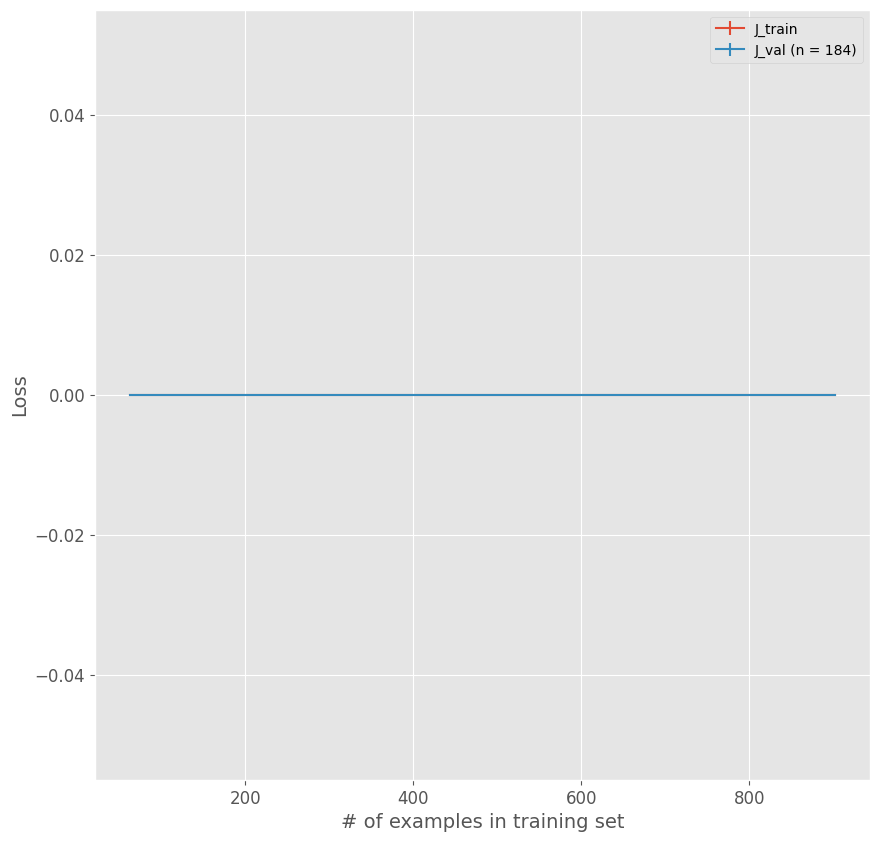

In [26]:
#C6
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, random_state=10, shuffle=True)
data_ratio = max_data_ratio(n_splits,X_train, Y_train)

J_train = np.zeros((2,len(data_ratio)))
J_val = np.zeros((2,len(data_ratio)))

pen = 'l2'
solver = check_penalty(penalty=pen)
lmb = best_lmbda
lmb = 10
for idx, curr_ratio in enumerate(data_ratio):
    #--------------------------Impelment your code here:-------------------------------------

    #----------------------------------------------------------------------------------------
    with tqdm(total=n_splits, file=sys.stdout, position=0, leave=True) as pbar:
        h = 0
        J_train_fold = np.zeros(n_splits)
        J_val_fold = np.zeros(n_splits)
        m_x_train, _, m_y_train, _ = train_test_split(x_train_orig, y_train, test_size =1-curr_ratio, random_state = 10,
                                             stratify=y_train)
        for train_index, val_index in skf.split(m_x_train, m_y_train):
            pbar.set_description('Dataset fraction is %.1f, processed folds' % curr_ratio)
            pbar.update()
            #--------------------------Impelment your code here:-------------------------------------

            #----------------------------------------------------------------------------------------
            h += 1
        #--------------------------Impelment your code here:-------------------------------------

        #----------------------------------------------------------------------------------------
fig, axes = plt.subplots(1,1,figsize=(10,10))
axes.errorbar(np.ceil(data_ratio[5:]*X_train.shape[0]), J_train[0,5:], yerr=J_train[1,5:])
axes.errorbar(np.ceil(data_ratio[5:]*X_train.shape[0]), J_val[0,5:], yerr=J_val[1,5:])
axes.set_xlabel('# of examples in training set')
axes.set_ylabel('Loss')
axes.legend(['J_train', 'J_val (n = ' + str(x_val_orig.shape[0]) + ')'])

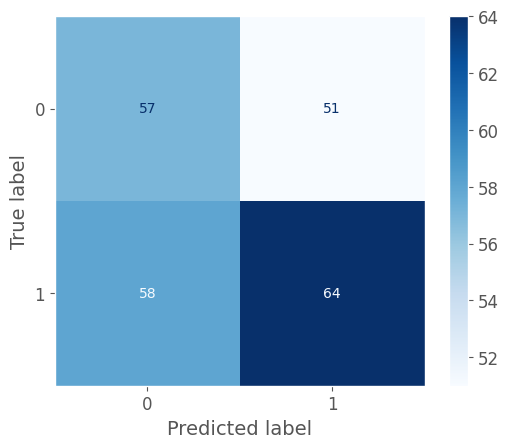

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
log_reg = LogisticRegression(random_state=5, penalty=pen, C = 1/best_lmbda, max_iter=max_iter,solver=solver)
x_tr = scaler.fit_transform(X_train)
x_tst = scaler.transform(x_test)
log_reg.fit(x_tr, Y_train)
y_pred_test = log_reg.predict(x_tst)
y_pred_proba_test = log_reg.predict_proba(x_tst)
ConfusionMatrixDisplay.from_estimator(log_reg, x_tst, y_test, cmap=plt.cm.Blues)
plt.grid(False)

In [30]:
from sklearn.metrics import confusion_matrix
calc_TN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 0]
calc_FP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 1]
calc_FN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 0]
calc_TP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 1]

In [32]:
from sklearn.metrics import roc_auc_score
#--------------------------Impelment your code here:-------------------------------------

#-----------------------------------------------------------------------------------------
print('AUROC is {:.2f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

AUROC is 0.56


In [33]:
from sklearn.model_selection import GridSearchCV
solver = 'liblinear'
log_reg = LogisticRegression(random_state=5, max_iter=max_iter,solver=solver)
lmbda = np.array([0.01, 0.01, 1, 10, 100, 1000])
pipe = Pipeline(steps=[('scale', StandardScaler()), ('logistic', log_reg)])
clf = GridSearchCV(estimator=pipe, param_grid={'logistic__C': 1/lmbda, 'logistic__penalty': ['l2']},
                   scoring=['accuracy','f1','precision','recall','roc_auc'], cv=skf,
                   refit='roc_auc', verbose=3, return_train_score=True)
clf.fit(X_train, Y_train)
clf.best_params_

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END logistic__C=100.0, logistic__penalty=l2; accuracy: (train=0.605, test=0.609) f1: (train=0.615, test=0.613) precision: (train=0.639, test=0.640) recall: (train=0.592, test=0.588) roc_auc: (train=0.655, test=0.658) total time=   0.0s
[CV 2/5] END logistic__C=100.0, logistic__penalty=l2; accuracy: (train=0.617, test=0.554) f1: (train=0.628, test=0.573) precision: (train=0.649, test=0.585) recall: (train=0.609, test=0.561) roc_auc: (train=0.667, test=0.610) total time=   0.0s
[CV 3/5] END logistic__C=100.0, logistic__penalty=l2; accuracy: (train=0.594, test=0.668) f1: (train=0.603, test=0.670) precision: (train=0.627, test=0.713) recall: (train=0.581, test=0.633) roc_auc: (train=0.645, test=0.695) total time=   0.0s
[CV 4/5] END logistic__C=100.0, logistic__penalty=l2; accuracy: (train=0.606, test=0.549) f1: (train=0.615, test=0.546) precision: (train=0.639, test=0.588) recall: (train=0.593, test=0.510) roc_auc: (trai

{'logistic__C': np.float64(100.0), 'logistic__penalty': 'l2'}

In [34]:
def plot_radar(clf,params,clf_type):
    labels=np.array(['Accuracy', 'F1', 'PPV', 'Sensitivity', 'AUROC'])
    score_mat_train = np.stack((clf.cv_results_['mean_train_accuracy'], clf.cv_results_['mean_train_f1'],
                               clf.cv_results_['mean_train_precision'], clf.cv_results_['mean_train_recall'],
                               clf.cv_results_['mean_train_roc_auc']), axis=0)
    score_mat_val = np.stack((clf.cv_results_['mean_test_accuracy'], clf.cv_results_['mean_test_f1'],
                               clf.cv_results_['mean_test_precision'], clf.cv_results_['mean_test_recall'],
                               clf.cv_results_['mean_test_roc_auc']), axis=0)


    angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    # close the plot

    angles=np.concatenate((angles,[angles[0]]))
    cv_dict = clf.cv_results_['params']
    # cv_dict = sorted(cv_dict, key=lambda k: k['logistic__penalty'])  # arrange dictionaries by penalties
    fig=plt.figure(figsize=(18,14))
    for idx, loc in enumerate(cv_dict):
        ax = fig.add_subplot(1, len(lmbda), 1+idx, polar=True)
        stats_train = score_mat_train[:, idx]
        stats_train=np.concatenate((stats_train,[stats_train[0]]))
        ax.plot(angles, stats_train, 'o-', linewidth=2)
        ax.fill(angles, stats_train, alpha=0.25)
        stats_val = score_mat_val[:, idx]
        stats_val=np.concatenate((stats_val,[stats_val[0]]))
        ax.plot(angles, stats_val, 'o-', linewidth=2)
        ax.fill(angles, stats_val, alpha=0.25)
        ax.set_thetagrids(angles[0:-1] * 180/np.pi, labels) #angles[0:-1]
        if idx == 0:
            ax.set_ylabel('$L_2$', fontsize=18)
        if cv_dict[idx]['logistic__C'] <= 1:
            ax.set_title('$\lambda$ = %d'  % (1 / cv_dict[idx]['logistic__C']))
        else:
            ax.set_title('$\lambda$ = %.3f' % (1 / cv_dict[idx]['logistic__C']))
        ax.set_ylim([0,1])
        ax.legend(['Train','Validation'])
        ax.grid(True)
    plt.show()



<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_14334/772179957.py:32: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title('$\lambda$ = %d'  % (1 / cv_dict[idx]['logistic__C']))
/tmp/ipykernel_14334/772179957.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title('$\lambda$ = %.3f' % (1 / cv_dict[idx]['logistic__C']))


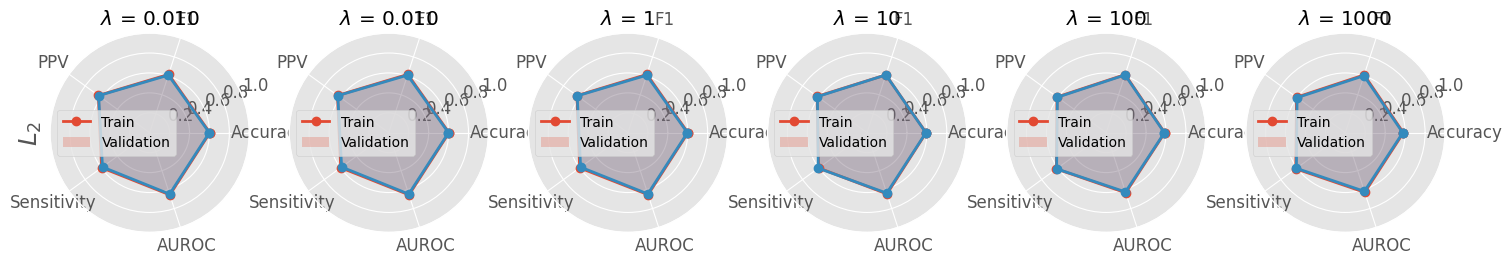

AUROC is 0.58


In [35]:
#C8
params = ['C', 'penalty']
clf_type = 'log_reg'
plot_radar(clf,params,clf_type)
chosen_clf = clf.best_estimator_
# print(chosen_clf)
y_pred_test = chosen_clf.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = chosen_clf.predict_proba(x_test)
#--------------------------Impelment your code here:-------------------------------------

#------------------------------------------------------------------------------------------
print('AUROC is {:.2f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

In [36]:
if not("results" in os.listdir()):
    os.mkdir("results")
with open('results/best_lin.pkl', 'wb') as f:
    pickle.dump(chosen_clf, f)